In [7]:
from __future__ import annotations

# stdlib
import json
import os
import shutil
import subprocess
import tempfile
import warnings
from pathlib import Path
from typing import Any
from xml.etree.ElementTree import Element
import pandas as pd

# third-party: numerics / scientific
import numpy as np
from numpy.random import default_rng
from scipy.spatial import cKDTree
from scipy.stats import truncnorm

# third-party: visualization / IO
import matplotlib.pyplot as plt
import pyvista as pv
import imageio.v2 as iio  # keep v2 for broad compatibility
import matplotlib as mpl

# progress bars
from tqdm import tqdm
from tqdm.notebook import tqdm as tqdm_nb

# domain-specific
import ogstools as ot
import porepy as pp

# notebook display
from IPython.display import Image, Markdown, display

In [2]:
user_parameters_rough = {
    "prefix": "roughFracture_synthesis_LF",
    "t_end": "100",
    "initial_dt": ".1",
    "minimum_dt": "1e-2",
    "maximum_dt": "10",
    "specific_body_force": "0 0 -9.81",
    "initial_pressure": {"type":"Constant","value":100000},     # "initial_pressure": {"expression":"1000*9.81*(z-0.015) + 1e5","type":"Function"},
    "outlet_pressure": {"type":"Constant","value":100000},
    "inlet_pressure": {"type":"Constant","value":500000},
    "inlet_concentration_value": "1.",
    "porosity_value": "0.005",
    "fluid_density": {
        "type": "Linear",
        "reference_value": "1000",
        "variable_name": "liquid_phase_pressure",
        "reference_condition": "1e5",
        "slope": "4.5e-7"
    },
    "equation_balance_type": "mass",
    'permeability_mesh_field': 'permeability_cubic',
    "fracture_thickness_mesh_field": "aperture_closed",

}

JRC_LIST = [4, 7]
sigmas_mpa = [0.2, 2.0]

## prj file helpers

In [3]:
def _xpath_param(name: str) -> str:
    return f".//parameters/parameter[name='{name}']"

def _ensure_parameter(project, name: str) -> str:
    """
    Ensure <parameter><name>name</name> exists. Return its base xpath.
    """
    base = _xpath_param(name)
    if project.tree.find(base) is None:
        project.add_element(".//parameters", "parameter")
        last = ".//parameters/parameter[last()]"
        project.add_element(last, "name", name)
    return base

def _clear_children(project, base_xpath: str, tags: list[str]) -> None:
    """
    Remove possibly-existing child tags under base_xpath.
    """
    for t in tags:
        project.remove_element(f"{base_xpath}/{t}")

def _set_parameter_constant_value(project, name: str, value: Any) -> None:
    base = _ensure_parameter(project, name)
    _clear_children(project, base, ["type", "value", "values", "field_name", "expression"])
    project.add_element(base, "type", "Constant")
    project.add_element(base, "value", str(value))

def _set_parameter_constant_values(project, name: str, values_text: str) -> None:
    base = _ensure_parameter(project, name)
    _clear_children(project, base, ["type", "value", "values", "field_name", "expression"])
    project.add_element(base, "type", "Constant")
    project.add_element(base, "values", str(values_text))

def _set_parameter_mesh_element(project, name: str, field_name: str) -> None:
    base = _ensure_parameter(project, name)
    _clear_children(project, base, ["type", "value", "values", "field_name", "expression"])
    project.add_element(base, "type", "MeshElement")
    project.add_element(base, "field_name", str(field_name))

def _set_parameter_function(project, name: str, expression: str) -> None:
    base = _ensure_parameter(project, name)
    _clear_children(project, base, ["type", "value", "values", "field_name", "expression"])
    project.add_element(base, "type", "Function")
    project.add_element(base, "expression", str(expression))

def _update_pressure_param(project, xml_name: str, spec: Any) -> None:
    """
    xml_name: parameter name in prj, e.g. 'p0', 'p_left', 'p_right'
    spec:
      - {"type":"Constant","value": ...}
      - {"expression":"...", "type":"Function"} or just "..."
    """
    if isinstance(spec, dict) and spec.get("type") == "Constant":
        _set_parameter_constant_value(project, xml_name, spec["value"])
    else:
        expr = spec if not isinstance(spec, dict) else spec.get("expression", "")
        _set_parameter_function(project, xml_name, expr)


def _ensure_density_property(project) -> str:
    """
    Ensure:
      .//media/medium/phases/phase[type='AqueousLiquid']/properties/property[name='density']
    exists and return xpath to that <property>.
    """
    prop_xpath = ".//media/medium/phases/phase[type='AqueousLiquid']/properties/property[name='density']"
    if project.tree.find(prop_xpath) is None:
        # create <property> inside AqueousLiquid/properties
        parent = ".//media/medium/phases/phase[type='AqueousLiquid']/properties"
        project.add_element(parent, "property")
        last = f"{parent}/property[last()]"
        project.add_element(last, "name", "density")
    return prop_xpath

def _update_density_property(project, density_spec: dict) -> None:
    prop_xpath = _ensure_density_property(project)

    # wipe old content except <name>
    _clear_children(project, prop_xpath, [
        "type", "value", "reference_value", "independent_variable",
    ])

    dtype = density_spec.get("type", "Constant")

    if dtype == "Constant":
        project.add_element(prop_xpath, "type", "Constant")
        project.add_element(prop_xpath, "value", str(density_spec.get("value", "1000")))
    elif dtype == "Linear":
        project.add_element(prop_xpath, "type", "Linear")
        project.add_element(prop_xpath, "reference_value", str(density_spec.get("reference_value", "1000")))
        # independent_variable subtree
        project.add_element(prop_xpath, "independent_variable")
        iv = f"{prop_xpath}/independent_variable"
        project.add_element(iv, "variable_name", str(density_spec.get("variable_name", "liquid_phase_pressure")))
        project.add_element(iv, "reference_condition", str(density_spec.get("reference_condition", "1e5")))
        project.add_element(iv, "slope", str(density_spec.get("slope", "4.5e-7")))
    else:
        raise ValueError("fluid_density.type must be 'Constant' or 'Linear'")

def _set_equation_balance_type(project, value: str) -> None:
    """
    Ensure <equation_balance_type> exists under the first process and set it.
    value must be 'mass' or 'volume'.
    """
    proc_xpath = ".//processes/process[1]"
    node = project.tree.find(f"{proc_xpath}/equation_balance_type")

    if node is None:
        project.add_element(proc_xpath, "equation_balance_type")
        node = project.tree.find(f"{proc_xpath}/equation_balance_type")

    # node is an Element; set its text
    node.text = str(value)


def update_project_parameters(project: "ot.Project", params: dict) -> None:
    # simple direct text replacements
    update_map = {
        "prefix": ".//time_loop/output/prefix",
        "inlet_concentration_value": ".//parameters/parameter[name='c_bottom']/value",
        "porosity_value": ".//parameters/parameter[name='constant_porosity_parameter']/value",
        "decay_Si_value": ".//parameters/parameter[name='decay']/value",
        "t_end": ".//time_loop/processes/process/time_stepping/t_end",
        "initial_dt": ".//time_loop/processes/process/time_stepping/initial_dt",
        "minimum_dt": ".//time_loop/processes/process/time_stepping/minimum_dt",
        "maximum_dt": ".//time_loop/processes/process/time_stepping/maximum_dt",
        "specific_body_force": ".//processes/process/specific_body_force",
        "longitudinal_dispersivity_value": ".//media/medium/properties/property[name='longitudinal_dispersivity']/value",
        "transversal_dispersivity_value": ".//media/medium/properties/property[name='transversal_dispersivity']/value",
    }

    for key, xpath in update_map.items():
        if key in params:
            project.replace_text(str(params[key]), xpath=xpath)

    # pressures
    if "initial_pressure" in params:
        _update_pressure_param(project, "p0", params["initial_pressure"])
    if "inlet_pressure" in params:
        _update_pressure_param(project, "p_left", params["inlet_pressure"])
    if "outlet_pressure" in params:
        _update_pressure_param(project, "p_right", params["outlet_pressure"])

    # permeability (either constant scalar -> tensor values OR mesh field)
    has_val   = "permeability_value" in params
    has_field = "permeability_mesh_field" in params
    if has_val and has_field:
        raise ValueError("Specify only one of 'permeability_value' or 'permeability_mesh_field'.")

    if has_val:
        perm_val = float(params["permeability_value"])
        vals = f"{perm_val} 0 0\n0 {perm_val} 0\n0 0 {perm_val}"
        _set_parameter_constant_values(project, "kappa1_frac", vals)
    elif has_field:
        _set_parameter_mesh_element(project, "kappa1_frac", params["permeability_mesh_field"])

    # fracture thickness (constant OR mesh field)
    has_wval   = "fracture_thickness_value" in params
    has_wfield = "fracture_thickness_mesh_field" in params
    if has_wval and has_wfield:
        raise ValueError("Specify only one of 'fracture_thickness_value' or 'fracture_thickness_mesh_field'.")

    if has_wval:
        _set_parameter_constant_value(project, "fracture_thickness_const", params["fracture_thickness_value"])
    elif has_wfield:
        _set_parameter_mesh_element(project, "fracture_thickness_const", params["fracture_thickness_mesh_field"])

    # fluid density (create or update)
    if "fluid_density" in params:
        _update_density_property(project, params["fluid_density"])

    # equation_balance_type
    # - if user explicitly provides it: respect it
    # - otherwise: choose automatically from density model
    if "equation_balance_type" in params:
        _set_equation_balance_type(project, str(params["equation_balance_type"]))
    else:
        # auto rule: Constant density -> volume, Linear density -> mass
        dens = params.get("fluid_density", {})
        dens_type = dens.get("type", "Constant") if isinstance(dens, dict) else "Constant"
        _set_equation_balance_type(project, "mass" if dens_type == "Linear" else "volume")

    
    # numerical stabilization (remove then optionally add)
    main_proc_xpath = ".//processes/process[1]"
    project.remove_element(f"{main_proc_xpath}/numerical_stabilization")

    if "numerical_stabilization" in params:
        stab = params["numerical_stabilization"]
        stype = stab.get("type")
        if not stype:
            raise ValueError("'type' is required in numerical_stabilization")

        project.add_element(main_proc_xpath, "numerical_stabilization")
        ns = f"{main_proc_xpath}/numerical_stabilization[last()]"
        project.add_element(ns, "type", stype)

        if stype == "FullUpwind":
            project.add_element(ns, "cutoff_velocity", str(stab.get("cutoff_velocity", "0.0")))
        elif stype == "IsotropicDiffusion":
            if "tuning_parameter" not in stab or "cutoff_velocity" not in stab:
                raise ValueError("'tuning_parameter' and 'cutoff_velocity' required for IsotropicDiffusion")
            project.add_element(ns, "tuning_parameter", str(stab["tuning_parameter"]))
            project.add_element(ns, "cutoff_velocity", str(stab["cutoff_velocity"]))
        elif stype == "FluxCorrectedTransport":
            pass
        else:
            raise ValueError(f"Unsupported stabilization type: {stype}")



## run simulation helpers

In [4]:
def find_2d_vtu_for_case(jrc: float, sigma: float, root="_out") -> Path:
    root = Path(root)
    s_tag = str(float(sigma)).replace(".", "p")

    # folder is JRC_4.0, JRC_7.0, ...
    folder = root / jrc_dir_name(jrc)

    # filename is joint_JRC4_sigma_0p2MPa.vtu
    fname = f"joint_JRC{int(jrc)}_sigma_{s_tag}MPa.vtu"
    p = folder / fname

    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}")
    return p

def jrc_dir_name(jrc) -> str:
        return f"JRC_{float(jrc):.1f}"

def _run_cmd(cmd, cwd: Path):
    subprocess.run(cmd, cwd=str(cwd), check=True)

def _set_project_meshes(project: "ot.Project", mesh_names: list[str]) -> None:
    meshes_xpath = ".//meshes"
    if project.tree.find(meshes_xpath) is None:
        project.add_element(".//OpenGeoSysProject", "meshes")

    while project.tree.find(".//meshes/mesh") is not None:
        project.remove_element(".//meshes/mesh")

    for m in mesh_names:
        project.add_element(meshes_xpath, "mesh", str(m))

def _ensure_aperture_and_cubic_perm(
    mesh_path: Path,
    ap_name: str = "aperture_closed",
    perm_name: str = "permeability_cubic",
    w_min=None,
):
    mesh = pv.read(str(mesh_path))

    if ap_name not in mesh.cell_data:
        raise KeyError(f"Cell field '{ap_name}' not found in: {mesh_path}")

    w = np.asarray(mesh.cell_data[ap_name], float)
    if w_min is not None:
        w = np.maximum(w, float(w_min))

    k = (w**2) / 12.0
    mesh.cell_data[ap_name] = w
    mesh.cell_data[perm_name] = k

    if "MaterialIDs" not in mesh.cell_data:
        mesh.cell_data["MaterialIDs"] = np.zeros(mesh.n_cells, dtype=np.int32)

    mesh.save(str(mesh_path))

def _extract_and_split_boundaries_2d(mesh_dir: Path, mesh_name_vtu: str):
    mesh_dir = Path(mesh_dir)
    original_file = mesh_name_vtu
    boundary_file = "boundaries.vtu"

    mesh = pv.read(str(mesh_dir / original_file))
    x_min, x_max, y_min, y_max, *_ = mesh.bounds

    h = max((x_max - x_min), (y_max - y_min)) / max(np.sqrt(mesh.n_points), 1.0)
    tol = 0.75 * h

    _run_cmd(["NodeReordering", "-i", original_file, "-o", original_file, "-m", "1"], cwd=mesh_dir)
    _run_cmd(["ExtractBoundary", "-i", original_file, "-o", boundary_file], cwd=mesh_dir)

    bnd = pv.read(str(mesh_dir / boundary_file))
    cc = bnd.cell_centers().points
    bnd.cell_data["cx"] = cc[:, 0]
    bnd.cell_data["cy"] = cc[:, 1]

    def pick_by_center(surf_, scalar, target, tol_):
        return surf_.threshold([target - tol_, target + tol_], scalars=scalar)

    left   = pick_by_center(bnd, "cx", x_min, tol)
    right  = pick_by_center(bnd, "cx", x_max, tol)
    bottom = pick_by_center(bnd, "cy", y_min, tol)
    top    = pick_by_center(bnd, "cy", y_max, tol)

    left.save(str(mesh_dir / "left.vtu"))
    right.save(str(mesh_dir / "right.vtu"))
    bottom.save(str(mesh_dir / "bottom.vtu"))
    top.save(str(mesh_dir / "top.vtu"))

    parts = ["left.vtu", "right.vtu", "bottom.vtu", "top.vtu"]
    _run_cmd(["identifySubdomains", "-m", original_file, *parts], cwd=mesh_dir)
    _run_cmd(["checkMesh", "-v", "-p", original_file], cwd=mesh_dir)

def _run_one_ogs_case(
    mesh_dir: Path,
    prj_template: Path,
    out_dir: Path,
    user_parameters: dict,
    main_mesh_name: str,
    boundary_meshes: list[str],
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    project = ot.Project(
        input_file=Path(prj_template),
        output_file=out_dir / Path(prj_template).name.replace(".prj", "_final.prj"),
    )

    _set_project_meshes(project, [main_mesh_name, *boundary_meshes])
    update_project_parameters(project, user_parameters)
    project.write_input()
    project.run_model(args=f"-o {out_dir} -m {mesh_dir}", logfile=out_dir / "run.log")

from pathlib import Path
import shutil

def _jrc_dir_name(jrc) -> str:
    # matches your actual folders: JRC_4.0, JRC_7.0, JRC_10.0
    return f"JRC_{float(jrc):.1f}"

def workflow_run_jrc_sigma(
    jrc_list,
    sigmas_mpa,
    user_parameters: dict,
    fracture_root_dir: str = "_out",
    fracture_mesh_pattern: str = "joint_JRC{jrc}_sigma_{s_tag}MPa.vtu",
    prj_template: str = "roughFracture_synthesis_LF.prj",
    base_run_dir: str = "_runs_ogs",
    boundary_meshes=None,
    w_min=None,
):
    fracture_root_dir = Path(fracture_root_dir)
    prj_template = Path(prj_template)
    base_run_dir = Path(base_run_dir)
    base_run_dir.mkdir(parents=True, exist_ok=True)

    if boundary_meshes is None:
        boundary_meshes = ["left.vtu", "right.vtu", "bottom.vtu", "top.vtu"]

    for jrc in jrc_list:
        jrc_int = int(float(jrc))  # safe if jrc is 4 or 4.0
        jrc_folder = _jrc_dir_name(jrc)  # <-- FIX: JRC_4.0 etc.

        for sigma in sigmas_mpa:
            s_tag = str(float(sigma)).replace(".", "p")

            # ---- 2D mesh location (per JRC)
            src_mesh = fracture_root_dir / jrc_folder / fracture_mesh_pattern.format(
                jrc=jrc_int, s_tag=s_tag
            )

            if not src_mesh.exists():
                print(f"skip JRC={jrc_int}, sigma={sigma}: missing {src_mesh}")
                continue

            # ---- case layout: .../_runs_ogs/JRC_{jrc}/sigma_{s_tag}/mesh|out
            case_dir = base_run_dir / f"JRC_{jrc_int}" / f"sigma_{s_tag}"
            mesh_dir = case_dir / "mesh"
            out_dir  = case_dir / "out"
            mesh_dir.mkdir(parents=True, exist_ok=True)
            out_dir.mkdir(parents=True, exist_ok=True)

            # copy mesh into mesh_dir
            dst_mesh = mesh_dir / src_mesh.name
            shutil.copy2(src_mesh, dst_mesh)

            # ensure fields used by prj exist
            _ensure_aperture_and_cubic_perm(dst_mesh, w_min=w_min)
            _extract_and_split_boundaries_2d(mesh_dir, dst_mesh.name)

            # params for this run
            params = dict(user_parameters)
            params["prefix"] = f"{params.get('prefix','roughFracture')}_JRC{jrc_int}_sigma_{s_tag}"
            params["permeability_mesh_field"] = "permeability_cubic"
            params["fracture_thickness_mesh_field"] = "aperture_closed"

            _run_one_ogs_case(
                mesh_dir=mesh_dir,
                prj_template=prj_template,
                out_dir=out_dir,
                user_parameters=params,
                main_mesh_name=dst_mesh.name,
                boundary_meshes=boundary_meshes,
            )

            print(f"✅ done JRC={jrc_int}, sigma={sigma} -> {case_dir}")




# run all simulations

In [5]:
workflow_run_jrc_sigma(
    jrc_list=JRC_LIST,
    sigmas_mpa=sigmas_mpa,
    user_parameters=user_parameters_rough,
    fracture_root_dir="_out",
    fracture_mesh_pattern="joint_JRC{jrc}_sigma_{s_tag}MPa.vtu",
    prj_template=f"{user_parameters_rough['prefix']}.prj",
    base_run_dir="_runs_ogs",
)

[2026-01-22 15:20:21.381] [ogs] [info] Reordering nodes... 
[2026-01-22 15:20:21.381] [ogs] [info] Corrected 0 elements.
[2026-01-22 15:20:21.393] [ogs] [info] VTU file written.
[2026-01-22 15:20:21.490] [ogs] [info] Mesh read: 10201 nodes, 20000 elements.
[2026-01-22 15:20:21.491] [ogs] [warning] Skipping property vector 'b0' - not defined on cells or nodes.
[2026-01-22 15:20:21.491] [ogs] [warning] Skipping property vector 'jrc' - not defined on cells or nodes.
[2026-01-22 15:20:21.491] [ogs] [warning] Skipping property vector 'lambda_max' - not defined on cells or nodes.
[2026-01-22 15:20:21.491] [ogs] [warning] Skipping property vector 'lambda_min' - not defined on cells or nodes.
[2026-01-22 15:20:21.491] [ogs] [warning] Skipping property vector 'nx' - not defined on cells or nodes.
[2026-01-22 15:20:21.491] [ogs] [warning] Skipping property vector 'ny' - not defined on cells or nodes.
[2026-01-22 15:20:21.491] [ogs] [warning] Skipping property vector 'seed' - not defined on cells

# Post-processing

Global |v| color scale: (2.9352687108711755e-31, 547.5546063341397)
saved: _plots_darcy/JRC4_sigma_0p2__darcy_v.png
saved: _plots_darcy/JRC4_sigma_2p0__darcy_v.png
saved: _plots_darcy/JRC7_sigma_0p2__darcy_v.png
saved: _plots_darcy/JRC7_sigma_2p0__darcy_v.png


/var/folders/r9/xlx2ppvs42n_h9_kk4w3r57m0000gp/T/ipykernel_15736/2582447004.py:271: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.get_cmap(cmap_name))
/var/folders/r9/xlx2ppvs42n_h9_kk4w3r57m0000gp/T/ipykernel_15736/2582447004.py:285: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


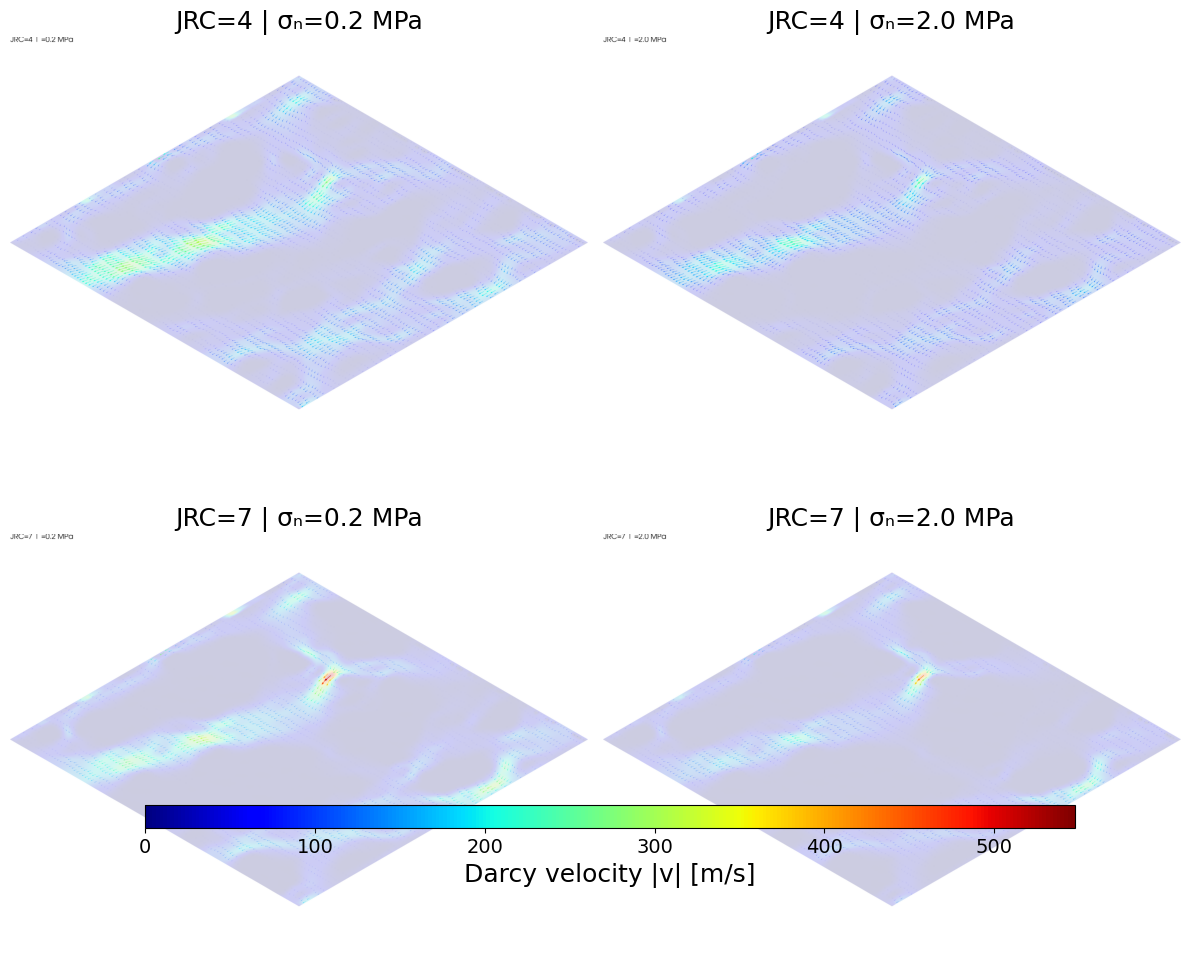

In [8]:
# ============================================================
# PLOTTING PIPELINE (JRC × sigma)
# ============================================================
# -----------------------------
# SETTINGS
# -----------------------------
BASE_RUN_DIR = Path("_runs_ogs")
OUT_IMG_DIR  = Path("_plots_darcy")
OUT_IMG_DIR.mkdir(parents=True, exist_ok=True)

cmap = "jet"
opacity = 0.2

use_cell_centers = True
downsample_every = 5
arrow_scale_frac = 0.02
min_mag = 1e-14
arrow_geom = pv.Arrow(tip_length=0.3, tip_radius=0.08, shaft_radius=0.02)


# -----------------------------
# Helpers
# -----------------------------
def mag(v):
    v = np.asarray(v)
    m = np.linalg.norm(v, axis=1)
    m[m <= 0] = min_mag
    return m


def find_pvd_for_jrc_sigma(jrc: int, sigma: float, base_run_dir=BASE_RUN_DIR) -> Path:
    """
    Expected folder structure:
      _runs_ogs/
        JRC_4/
          sigma_0p2/
            out/*.pvd
    """
    s_tag = str(float(sigma)).replace(".", "p")
    out_dir = Path(base_run_dir) / f"JRC_{int(jrc)}" / f"sigma_{s_tag}" / "out"
    pvds = sorted(out_dir.glob("*.pvd"))
    if not pvds:
        raise FileNotFoundError(f"No .pvd found in: {out_dir}")
    return pvds[0]


def load_last_surface(pvd_file: Path):
    series = ot.MeshSeries(str(pvd_file))
    mesh = series[len(series) - 1]  # last time step
    surf = mesh.extract_surface()

    sampled_pts = mesh.sample(surf)
    if "v" not in sampled_pts.array_names:
        raise KeyError(
            f"'v' not found in {pvd_file}. Ensure secondary_variable darcy_velocity output_name='v'."
        )
    surf["v_mag"] = mag(sampled_pts["v"])
    return mesh, surf


def build_glyphs(mesh, surf):
    if use_cell_centers:
        centers = surf.cell_centers()
        sampled_c = centers.sample(mesh)
        centers["v"] = sampled_c["v"]
        centers["v_mag"] = mag(centers["v"])
    else:
        centers = pv.PolyData(surf.points)
        sampled_c = centers.sample(mesh)
        centers["v"] = sampled_c["v"]
        centers["v_mag"] = mag(centers["v"])

    if downsample_every and downsample_every > 1 and centers.n_points > 0:
        keep = np.arange(centers.n_points)[::downsample_every]
        centers = centers.extract_points(keep, include_cells=False)

    diag = float(mesh.length)
    max_mag = float(np.max(centers["v_mag"])) if centers.n_points else 1.0
    factor = (diag * arrow_scale_frac) / max(max_mag, min_mag)

    glyphs = centers.glyph(
        orient="v",
        scale="v_mag",
        factor=factor,
        geom=arrow_geom,
    )
    return glyphs


def render_case_to_png(
    pvd_file: Path,
    png_file: Path,
    title: str,
    clim,
    window_size=(2600, 1800),
    scale=2,
    show_axes=False,
    zoom=1.8,            # <--- smaller => more zoomed-out view? (actually zoom<1 zooms out, >1 zooms in)
    zoom_out_factor=1.0, # <--- use this to zoom OUT (e.g., 0.9)
):
    """
    IMPORTANT: no scalarbar here. We will add ONE shared colorbar in matplotlib.
    """
    mesh, surf = load_last_surface(pvd_file)
    glyphs = build_glyphs(mesh, surf)

    p = pv.Plotter(off_screen=True, window_size=window_size)
    p.set_background("white")

    # Title (bigger)
    p.add_text(title, font_size=28, position="upper_left")

    # surface (NO scalarbar)
    p.add_mesh(
        surf,
        scalars="v_mag",
        cmap=cmap,
        clim=clim,
        opacity=opacity,
        show_edges=False,
        show_scalar_bar=False,  
    )

    # arrows
    p.add_mesh(
        glyphs,
        scalars="v_mag",
        cmap=cmap,
        clim=clim,
        lighting=False,
        show_scalar_bar=False,
    )

    # Camera: frame surface bounds
    p.enable_parallel_projection()
    p.reset_camera(bounds=surf.bounds)

    # zoom controls:
    # - PyVista: zoom > 1 zooms IN, zoom < 1 zooms OUT
    # We'll interpret zoom_out_factor < 1 to zoom out slightly
    if zoom_out_factor is None:
        zoom_out_factor = 1.0

    # Your old zoom was ~2 (too zoomed in). This is nicer:
    p.camera.zoom(float(zoom_out_factor))

    if show_axes:
        p.show_axes()

    p.screenshot(str(png_file), scale=scale)
    p.close()


def render_all_jrc_sigma(
    jrc_list,
    sigmas_mpa,
    base_run_dir=BASE_RUN_DIR,
    out_img_dir=OUT_IMG_DIR,
    window_size=(2600, 1800),
    scale=2,
    zoom_out_factor=0.92,   # <--- 0.90~0.95 zooms OUT a bit
):
    """
    Returns:
      png_map: dict[(jrc, sigma)] -> Path or None (if missing)
      clim: (vmin, vmax) computed from existing cases
    """
    out_img_dir = Path(out_img_dir)
    out_img_dir.mkdir(parents=True, exist_ok=True)

    # ---- collect cases (and tolerate missing)
    cases = []
    missing = []
    for jrc in jrc_list:
        for sigma in sigmas_mpa:
            try:
                pvd = find_pvd_for_jrc_sigma(jrc, sigma, base_run_dir=base_run_dir)
                cases.append((int(jrc), float(sigma), pvd))
            except FileNotFoundError as e:
                missing.append((int(jrc), float(sigma), str(e)))

    if missing:
        for jrc, sigma, msg in missing:
            print(f"skip JRC={jrc}, sigma={sigma}: {msg}")

    if not cases:
        raise RuntimeError("No cases found. Check your _runs_ogs folder structure.")

    # ---- global clim over all FOUND cases
    vmins, vmaxs = [], []
    for jrc, sigma, pvd in cases:
        _, surf = load_last_surface(pvd)
        vmins.append(float(surf["v_mag"].min()))
        vmaxs.append(float(surf["v_mag"].max()))
    clim = (float(np.min(vmins)), float(np.max(vmaxs)))
    print("Global |v| color scale:", clim)

    # ---- render each FOUND case
    png_map = {}
    for jrc, sigma, pvd in cases:
        s_tag = str(float(sigma)).replace(".", "p")
        png_file = out_img_dir / f"JRC{jrc}_sigma_{s_tag}__darcy_v.png"
        title = f"JRC={jrc} | σₙ={sigma} MPa"
        render_case_to_png(
            pvd_file=pvd,
            png_file=png_file,
            title=title,
            clim=clim,
            window_size=window_size,
            scale=scale,
            zoom_out_factor=zoom_out_factor,
        )
        png_map[(jrc, sigma)] = png_file
        print("saved:", png_file)

    # mark missing as None in map so grid can show blanks
    for jrc in jrc_list:
        for sigma in sigmas_mpa:
            key = (int(jrc), float(sigma))
            png_map.setdefault(key, None)

    return png_map, clim


def plot_grid_with_shared_colorbar(
    png_map,
    jrc_list,
    sigmas_mpa,
    clim,
    cmap_name="rainbow",
    figsize=None,
    cbar_label="Darcy velocity |v| [m/s]",
    title_fontsize=18,
    cbar_fontsize=18,
    cbar_ticksize=14,
):
    nrows = len(jrc_list)
    ncols = len(sigmas_mpa)

    if figsize is None:
        figsize = (6 * ncols, 4.8 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)

    # normalize axes shape
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    for i, jrc in enumerate(jrc_list):
        for j, sigma in enumerate(sigmas_mpa):
            ax = axes[i, j]
            key = (int(jrc), float(sigma))
            png = png_map.get(key, None)

            if png is None:
                ax.set_title(f"JRC={int(jrc)} | σₙ={float(sigma)} MPa\n(missing)", fontsize=title_fontsize)
                ax.axis("off")
                continue

            img = plt.imread(png)
            ax.imshow(img)
            ax.set_title(f"JRC={int(jrc)} | σₙ={float(sigma)} MPa", fontsize=title_fontsize)
            ax.axis("off")

    # ---- ONE shared colorbar at bottom
    norm = mpl.colors.Normalize(vmin=clim[0], vmax=clim[1])
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.get_cmap(cmap_name))
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.06,
        pad=0.06,
        aspect=40,
    )
    cbar.set_label(cbar_label, fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=cbar_ticksize)

    plt.tight_layout()
    return fig


# ============================================================
# RUN (EXAMPLE)
# ============================================================


png_map, clim = render_all_jrc_sigma(
    jrc_list=JRC_LIST,
    sigmas_mpa=sigmas_mpa,
    base_run_dir=BASE_RUN_DIR,
    out_img_dir=OUT_IMG_DIR,
    window_size=(2800, 2000),
    scale=2,
    zoom_out_factor=1.4,   # <--- zoom OUT a bit (try 0.88..0.95)
)

fig = plot_grid_with_shared_colorbar(
    png_map=png_map,
    jrc_list=JRC_LIST,
    sigmas_mpa=sigmas_mpa,
    clim=clim,
    cmap_name=cmap,
    figsize=(6*len(sigmas_mpa), 5*len(JRC_LIST)),
    cbar_label="Darcy velocity |v| [m/s]",
)
plt.show()

In [9]:
# -----------------------------
# Utilities
# -----------------------------
def _safe_norm(arr) -> np.ndarray:
    arr = np.asarray(arr)
    if arr.ndim != 2 or arr.shape[1] != 3:
        raise ValueError(f"Expected vector array shape (N,3), got {arr.shape}")
    return np.linalg.norm(arr, axis=1)

def _pick_first_existing_field(mesh, candidates, where="cell_data"):
    data = getattr(mesh, where)
    for name in candidates:
        if name in data:
            return name
    return None

def _fmt3(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "   -    "
    return f"{x:.3e}"

def _fmtf(x, nd=3):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "  -  "
    return f"{x:.{nd}f}"

def _tag_sigma_dirname(dir_name: str) -> str:
    # "sigma_0p2" -> "0.2"
    if dir_name.startswith("sigma_"):
        s = dir_name.replace("sigma_", "").replace("p", ".")
        return s
    return dir_name

def _parse_case_from_pvd(pvd: Path):
    """
    Supports both layouts:
      A) _runs_ogs/sigma_0p2/out/*.pvd
      B) _runs_ogs/JRC_7/sigma_0p2/out/*.pvd
    """
    out_dir = pvd.parent          # .../out
    sigma_dir = out_dir.parent    # .../sigma_0p2
    sigma_tag = sigma_dir.name
    sigma_str = _tag_sigma_dirname(sigma_tag)

    jrc = None
    if sigma_dir.parent.name.startswith("JRC_"):
        # .../JRC_7/sigma_0p2/out
        try:
            jrc = float(sigma_dir.parent.name.replace("JRC_", ""))
        except Exception:
            jrc = None

    # pretty label for printing
    case_label = []
    if jrc is not None:
        case_label.append(f"JRC={jrc:g}")
    case_label.append(f"σn={sigma_str} MPa")
    case_label.append(pvd.stem)
    return jrc, sigma_str, " | ".join(case_label)

# -----------------------------
# Main verifier
# -----------------------------
def verify_all_cases(
    base_run_dir="_runs_ogs",
    aperture_candidates=("aperture_closed", "aperture_mid", "aperture_raw"),
    contact_field="contact",
    vec_field="v",
    max_print=9999,          # limit printed cases
    return_dataframe=True,   # also return a DataFrame for sorting/filtering
):
    base = Path(base_run_dir)

    # Find pvds in both layouts
    pvds = sorted(base.rglob("out/*.pvd"))
    if not pvds:
        raise FileNotFoundError(f"No .pvd found under: {base}/**/out/*.pvd")

    print(f"Found {len(pvds)} case(s) under {base}")

    rows = []
    printed = 0

    for pvd in pvds:
        jrc, sigma_str, case_title = _parse_case_from_pvd(pvd)

        try:
            series = ot.MeshSeries(str(pvd))
            mesh = series[len(series) - 1]  # last timestep

            # ---- v on points
            has_v_pt = vec_field in mesh.point_data
            v_pt_min = v_pt_mean = v_pt_max = np.nan
            if has_v_pt:
                vmag_pt = _safe_norm(mesh.point_data[vec_field])
                v_pt_min, v_pt_mean, v_pt_max = map(float, (vmag_pt.min(), vmag_pt.mean(), vmag_pt.max()))

            # ---- v sampled at cell centers (better for contact/open splits)
            cent = mesh.cell_centers()
            sampled = cent.sample(mesh)
            has_v_cell = vec_field in sampled.point_data  # sample result stores in point_data
            v_cell_min = v_cell_mean = v_cell_max = np.nan
            v_contact_min = v_contact_mean = v_contact_max = np.nan
            v_open_min = v_open_mean = v_open_max = np.nan

            if has_v_cell:
                v_cell = np.asarray(sampled.point_data[vec_field])
                vmag_cell = _safe_norm(v_cell)
                v_cell_min, v_cell_mean, v_cell_max = map(float, (vmag_cell.min(), vmag_cell.mean(), vmag_cell.max()))

            # ---- contact + aperture (cell data)
            has_contact = contact_field in mesh.cell_data
            contact_frac = np.nan
            contact = None
            if has_contact:
                contact = np.asarray(mesh.cell_data[contact_field]).astype(bool)
                contact_frac = float(contact.mean())

            ap_field = _pick_first_existing_field(mesh, aperture_candidates, where="cell_data")
            has_ap = ap_field is not None

            w_min = w_mean = w_max = np.nan
            w_zero = w_neg = np.nan
            w_contact_min = w_contact_max = np.nan
            w_open_min = w_open_max = np.nan


            if has_ap:
                w = np.asarray(mesh.cell_data[ap_field], float)
            
                # ---- derive contact from aperture (instead of reading contact_field)
                eps = 1e-15  # meters
                contact = (w <= eps)
                has_contact = True
                contact_frac = float(contact.mean())
            
                w_min, w_mean, w_max = map(float, (w.min(), w.mean(), w.max()))
                w_zero = int(np.count_nonzero(w == 0.0))
                w_neg  = int(np.count_nonzero(w < 0.0))
            
                if np.any(contact):
                    w_contact_min = float(w[contact].min())
                    w_contact_max = float(w[contact].max())
                if np.any(~contact):
                    w_open_min = float(w[~contact].min())
                    w_open_max = float(w[~contact].max())
            

            # ---- v(contact/open) using cell-center vmag and contact mask (must align with cells)
            mismatch = None
            if has_contact and has_v_cell and (contact is not None):
                # vmag_cell is per-cell-center (same count as n_cells in typical cases)
                if contact.size == vmag_cell.size:
                    if np.any(contact):
                        v_contact_min = float(vmag_cell[contact].min())
                        v_contact_mean = float(vmag_cell[contact].mean())
                        v_contact_max = float(vmag_cell[contact].max())
                    if np.any(~contact):
                        v_open_min = float(vmag_cell[~contact].min())
                        v_open_mean = float(vmag_cell[~contact].mean())
                        v_open_max = float(vmag_cell[~contact].max())
                else:
                    mismatch = f"contact({contact.size}) != v_cell({vmag_cell.size})"


            row = {
                "pvd": str(pvd),
                "jrc": jrc,
                "sigma_mpa_str": sigma_str,
                "case_title": case_title,

                "has_v_pt": has_v_pt,
                "v_pt_min": v_pt_min, "v_pt_mean": v_pt_mean, "v_pt_max": v_pt_max,

                "has_v_cell": has_v_cell,
                "v_cell_min": v_cell_min, "v_cell_mean": v_cell_mean, "v_cell_max": v_cell_max,

                "has_contact": has_contact,
                "contact_frac": contact_frac,
                "contact_vs_vcell_mismatch": mismatch,

                "aperture_field": ap_field,
                "has_aperture": has_ap,
                "w_min": w_min, "w_mean": w_mean, "w_max": w_max,
                "w_zero": w_zero, "w_neg": w_neg,
                "w_contact_min": w_contact_min, "w_contact_max": w_contact_max,
                "w_open_min": w_open_min, "w_open_max": w_open_max,

                "v_contact_min": v_contact_min, "v_contact_mean": v_contact_mean, "v_contact_max": v_contact_max,
                "v_open_min": v_open_min, "v_open_mean": v_open_mean, "v_open_max": v_open_max,
            }
            rows.append(row)

            # ---- pretty console output
            if printed < max_print:
                printed += 1
                print("\n" + "=" * 80)
                print(case_title)
                print("-" * 80)

                print(f"|v| points : "
                      f"min/mean/max = {_fmt3(v_pt_min)} / {_fmt3(v_pt_mean)} / {_fmt3(v_pt_max)}"
                      f"   ({'OK' if has_v_pt else 'MISSING'})")

                print(f"|v| cells  : "
                      f"min/mean/max = {_fmt3(v_cell_min)} / {_fmt3(v_cell_mean)} / {_fmt3(v_cell_max)}"
                      f"   ({'OK' if has_v_cell else 'MISSING'})")

                if has_contact:
                    msg = f"contact  : fraction = {_fmtf(contact_frac,3)}"
                    if mismatch:
                        msg += f"   ⚠ {mismatch}"
                    print(msg)
                else:
                    print("contact  : MISSING")

                if has_ap:
                    print(f"aperture  : field = '{ap_field}'")
                    print(f"           min/mean/max = {_fmt3(w_min)} / {_fmt3(w_mean)} / {_fmt3(w_max)}")
                    print(f"           zeros={w_zero}  negatives={w_neg}")
                    if has_contact and contact is not None:
                        if not (isinstance(w_contact_min, float) and np.isnan(w_contact_min)):
                            print(f"           w(contact) min/max = {_fmt3(w_contact_min)} / {_fmt3(w_contact_max)}")
                        if not (isinstance(w_open_min, float) and np.isnan(w_open_min)):
                            print(f"           w(open)    min/max = {_fmt3(w_open_min)} / {_fmt3(w_open_max)}")
                else:
                    print(f"aperture  : MISSING (tried {list(aperture_candidates)})")

                if has_contact and has_v_cell and contact is not None and mismatch is None:
                    if not (isinstance(v_contact_min, float) and np.isnan(v_contact_min)):
                        print(f"|v| contact: min/mean/max = {_fmt3(v_contact_min)} / {_fmt3(v_contact_mean)} / {_fmt3(v_contact_max)}")
                    if not (isinstance(v_open_min, float) and np.isnan(v_open_min)):
                        print(f"|v| open   : min/mean/max = {_fmt3(v_open_min)} / {_fmt3(v_open_mean)} / {_fmt3(v_open_max)}")

        except Exception as e:
            print("\n" + "=" * 80)
            print(case_title)
            print("ERROR:", e)
            rows.append({
                "pvd": str(pvd),
                "jrc": jrc,
                "sigma_mpa_str": sigma_str,
                "case_title": case_title,
                "error": str(e),
            })

    if not return_dataframe:
        return rows

    df = pd.DataFrame(rows)

    # nice default ordering if present
    sort_cols = [c for c in ["jrc", "sigma_mpa_str", "case_title"] if c in df.columns]
    if sort_cols:
        df = df.sort_values(sort_cols, na_position="last").reset_index(drop=True)

    # quick summary
    ok = df["error"].isna() if "error" in df.columns else np.ones(len(df), dtype=bool)
    print("\n" + "=" * 80)
    print("SUMMARY")
    print("-" * 80)
    print(f"  total cases        : {len(df)}")
    print(f"  ok                 : {int(ok.sum())}")
    print(f"  errors             : {int((~ok).sum())}")
    if "aperture_field" in df.columns:
        print("  aperture fields    :")
        print(df.loc[ok, "aperture_field"].value_counts(dropna=False).to_string())

    return df


# -----------------------------
# Run
# -----------------------------
df = verify_all_cases(
    base_run_dir="_runs_ogs",
    aperture_candidates=("aperture_closed", "aperture_mid", "aperture_raw"),
    contact_field="contact_closed",
    max_print=9999,
    return_dataframe=True,
)

df

Found 4 case(s) under _runs_ogs

JRC=4 | σn=0.2 MPa | roughFracture_synthesis_LF_JRC4_sigma_0p2
--------------------------------------------------------------------------------
|v| points : min/mean/max = 0.000e+00 / 6.440e+01 / 3.107e+02   (OK)
|v| cells  : min/mean/max = 0.000e+00 / 6.425e+01 / 3.087e+02   (OK)
contact  : fraction = 0.073
aperture  : field = 'aperture_closed'
           min/mean/max = 0.000e+00 / 5.021e-04 / 1.837e-03
           zeros=1466  negatives=0
           w(contact) min/max = 0.000e+00 / 0.000e+00
           w(open)    min/max = 2.020e-07 / 1.837e-03
|v| contact: min/mean/max = 0.000e+00 / 4.478e-01 / 1.981e+01
|v| open   : min/mean/max = 2.329e-02 / 6.929e+01 / 3.087e+02

JRC=4 | σn=2.0 MPa | roughFracture_synthesis_LF_JRC4_sigma_2p0
--------------------------------------------------------------------------------
|v| points : min/mean/max = 0.000e+00 / 4.435e+01 / 2.674e+02   (OK)
|v| cells  : min/mean/max = 0.000e+00 / 4.421e+01 / 2.531e+02   (OK)
contact  

,pvd,jrc,sigma_mpa_str,case_title,has_v_pt,v_pt_min,v_pt_mean,v_pt_max,has_v_cell,v_cell_min,...,w_contact_min,w_contact_max,w_open_min,w_open_max,v_contact_min,v_contact_mean,v_contact_max,v_open_min,v_open_mean,v_open_max
0,_runs_ogs/JRC_4/sigma_0p2/out/roughFracture_sy...,4.0,0.2,JRC=4 | σn=0.2 MPa | roughFracture_synthesis_L...,True,0.0,64.404603,310.690692,True,0.0,...,0.0,0.0,2.019788e-07,0.001837,0.0,0.447797,19.806386,2.328715e-02,69.293218,308.651873
1,_runs_ogs/JRC_4/sigma_2p0/out/roughFracture_sy...,4.0,2.0,JRC=4 | σn=2.0 MPa | roughFracture_synthesis_L...,True,0.0,44.351597,267.445197,True,0.0,...,0.0,0.0,2.855413e-08,0.001765,0.0,0.308829,13.256667,2.105578e-15,49.640367,253.079232
2,_runs_ogs/JRC_7/sigma_0p2/out/roughFracture_sy...,7.0,0.2,JRC=7 | σn=0.2 MPa | roughFracture_synthesis_L...,True,0.0,52.947676,547.554606,True,0.0,...,0.0,0.0,2.813056e-07,0.002703,0.0,0.396728,65.692580,2.974490e-14,65.626463,517.467696
3,_runs_ogs/JRC_7/sigma_2p0/out/roughFracture_sy...,7.0,2.0,JRC=7 | σn=2.0 MPa | roughFracture_synthesis_L...,True,0.0,34.987731,455.202476,True,0.0,...,0.0,0.0,1.825334e-07,0.002631,0.0,0.281923,44.579913,5.375172e-15,45.724486,428.890469
